In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np
from skbio.diversity import beta_diversity
from skbio.diversity import alpha_diversity
from skbio.stats.ordination import pcoa
from skbio.stats.distance import anosim

/home/huayuqin/miniconda3/envs/soil/lib/python3.11/site-packages/numpy/core/getlimits.py:542: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [24]:
otu_tab = pd.read_csv('../pre-calculated_data/all_otu_table.S3.5.rib_prot_S2_rpsB.ebd', sep='\t', index_col=0)
otu_tab

,AAAAAAAACGCGAACCGCTACGCCCGCAAGGTCGGATTTACGTCGGTGGCGTTGATCGAC,AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAAAAGAACGCCATCAGCGAATCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAAAAGAACGCCGTGAAAGAAGCCCGCAAGCTGGGCATCGCCACGGTGGCGCTCATCGAC,AAAAAGATAGCCAACAAAGAAGCGCACCGGCTCAAAAAAAACGTCGCGGCAATCGTCCAA,AAAAATATTGCATTGAAAGAAGCGCAGAGATTAAACGTAAACACTTTTGGAATTGTTGAT,AAAAATGGGGCGCTCGCGGAAGCGAAGCGACTCGGCATTCCGATCGTTGGCATCGTCGAT,AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,AAACACAACGCCGTTGCTGAGGCGCGTCGGCTCAAAATCCCGGTCGTCGCGATAGTGGAT,AAACACAACGCGGTGAAGGAAGCCCGCCGCCTGTCGATCCCGGTCATCGCCATGCTCGAC,...,TGCGCAGTTCGTATCGACGACTGCAACGACAGGAATACCGAGCTTCTTGGCTTCGTGAAT,TGGAGAATCTGTGTCACAGAGAGCAATAACGGGAATGTTGACGTAGCTGGCCTCCTTGAT,TGGCACCTGGCGGTCGAGGAGGCCCGCAAGCTGCGGATCCCGATCATCGGCATCCTCGAC,TGTGAAAATGTTTCAGATGAATTTGCTTCAGCTAACATTCCAACTATAGGAATTGTTGAC,TTCAGAGAAGTTGTATCTGAAGCTTATGATATGGAGATTCCAGTTGTTGCGGCAATGGAT,TTGAAGATCTCGATAATGGTTGGCCGGGCACTCCGCATAAAAACAGTCTCGATGATCGAC,TTGAATATCGCATTCACAGAAGCAATACGGCTGGGTATGGGTACTTTCGGGATGGTGGAG,TTGCGCATCGCGGTCAGCGAGGCGAACAAGCTGGGCATCCCGATCGTCGCTATGGTGGAC,TTTGCTGCAGCGATAAAAGAGGCTTCATCCTTGAGTATTCCATCGTTAGGATTGATGGAT,TTTTATTCGTGTTTTTTTGAATCGACTTATTGTGGAATTCCGGCTATTGGTATGATTGAT
CPSNJ01_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ02_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ03_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ04_350,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ08_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ09_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ10_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ11_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ13_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ14_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
#remove samples (<100 total count OTUs)
otus_filt = otu_tab[otu_tab.sum(axis=1) >= 100]
otus_filt_wo0 = otus_filt[otus_filt.sum(axis=1) > 0]
otus_filt_wo0 = otus_filt_wo0.loc[:,otus_filt_wo0.sum(axis=0) > 0]

otus_filt_wo0['Sum'] = otus_filt_wo0.sum(axis=1)
otus_RA = otus_filt_wo0.iloc[:, :].div(otus_filt_wo0.Sum, axis=0)
otus_RA = otus_RA.drop(['Sum'], axis=1)

#remove low RA
otus_RA = otus_RA.T
otus_RA['Mean'] = otus_RA.mean(axis=1)
otus_RA_filt = otus_RA.loc[otus_RA['Mean'].between(0.00001, 1)]
otus_RA_filt = otus_RA_filt.drop(['Mean'], axis=1)
otus_RA_filt 

,CPSNJ01_350,CPSNJ02_350,CPSNJ03_350,CPSNJ04_350,CPSNJ08_350,CPSNJ09_350,CPSNJ10_350,CPSNJ11_350,CPSNJ13_350,CPSNJ14_350,...,SNJ08_350,SNJ09_350,SNJ10_350,SNJ11_350,SNJ13_350,SNJ14_350,SNJ15_350,SNJ16_350,SNJ19_350,SNJ20_350
AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000809,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
AACCACACCCTGCTGCACGAGTGCGGCCTCGCCTCCATCCCAACCATCGGCGTCATCGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
AACCAGATTGCCATCAAGGAGGCCACCAAGTTCCACATCCCCACCATCGGCATCACAGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
AACTACACCCTCTTGTATGAGTGTGCATTAGCTACCATCCCCACCATTGGCGTCATTGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTTGCTGTTGGTATCGACAACGCCGATGACCGGAATACCCAGCTTGTTGGCTTCCTGGAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
GTTGGCGTTCGTATCCACAATGCCCATCACAGGGATGCGCAGTGTGTTGGCTTCTTTGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
TACCACGCTGCCGTCCGCGAGGCGGTGCGTGCTGGCGTGCCCATCATCGCGTTTGCAAAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.00000
TGAACAGTTGGTGTCAACGACGGCAACGATGGGGATATCAAGCCTGTTGGCTTCTTTGAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000258,0.0,0.0,0.000782,0.0,0.0,0.0,0.0,0.0,0.00019


In [26]:
otus_RA_filt = otus_RA_filt.T
otus_RA_filt

,AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,AACCACACCCTGCTGCACGAGTGCGGCCTCGCCTCCATCCCAACCATCGGCGTCATCGAC,AACCAGATTGCCATCAAGGAGGCCACCAAGTTCCACATCCCCACCATCGGCATCACAGAC,AACTACACCCTCTTGTATGAGTGTGCATTAGCTACCATCCCCACCATTGGCGTCATTGAC,AATTATATAATATGTAATGAGGCTATATCTATGTTTTTGCCTATTATTGCAATAGTTGAC,AATTATATAGTTTTAAAAGAAGCCGCTTTAATGTTTATGCCTGTTATAGGTATTATTGAT,ACACATCCAGCAGTCGTCGATTCGGCTAAACTCCTGATCCCGACCGTCGGTATTGTTGAC,AGAACAATTTGTGTCGACGACTGCAACGATGGGGATGCCCAGACGATTAGCTTCAGCGAC,AGCGCCAACGCCGTGCGCGAAGCCCGTAAAATGCGCTTGCCAATCGTAGCCGTTGTCGAC,...,GTCGGCGTTGGTGTCCACGATGCCAACGATGGGGATGCCGAGACGGTTGGCTTCCTTGAC,GTGAAGAACGCCGCGAAGCAGGCCGCCGACGCCGGCATCCCCATCGTCTCCATCGAGGGC,GTTAGCGTTAGTGTCAACGAGACCAACAACAGGCACACCAAGTGTCTTTGCTTCCTTAAC,GTTGCAGTTGGTATCGACGAGTGCAACGATCGGGATATTGAGCAGGTTTGCTTCGTGGAC,GTTGCAGTTGGTATCGACGATGGCCACGGTGGTAATGCCCAGCTTGTTTGCTTCGTGAAC,GTTGCTGTTGGTATCGACAACGCCGATGACCGGAATACCCAGCTTGTTGGCTTCCTGGAT,GTTGGCGTTCGTATCCACAATGCCCATCACAGGGATGCGCAGTGTGTTGGCTTCTTTGAC,TACCACGCTGCCGTCCGCGAGGCGGTGCGTGCTGGCGTGCCCATCATCGCGTTTGCAAAC,TGAACAGTTGGTGTCAACGACGGCAACGATGGGGATATCAAGCCTGTTGGCTTCTTTGAT,TGAACAGTTTGTATCGACCACTGCAAAAACCGGAATGCCGAGCTTGTTGGCTTCAGCGAC
CPSNJ01_350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000886,0.000000,0.000000,0.000222,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CPSNJ02_350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000501,0.000000,0.000000,0.000000,0.000000,0.000000
CPSNJ03_350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CPSNJ04_350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CPSNJ08_350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CPSNJ09_350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CPSNJ10_350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CPSNJ11_350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CPSNJ13_350,0.000000,0.000809,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CPSNJ14_350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [27]:
binary_otus = np.where(otus_RA_filt != 0, 1, 0)
binary_otus

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 1]])

In [28]:
otus_rows = otus_RA_filt.index.tolist()
otus_rows

['CPSNJ01_350',
 'CPSNJ02_350',
 'CPSNJ03_350',
 'CPSNJ04_350',
 'CPSNJ08_350',
 'CPSNJ09_350',
 'CPSNJ10_350',
 'CPSNJ11_350',
 'CPSNJ13_350',
 'CPSNJ14_350',
 'CPSNJ15_350',
 'CPSNJ16_350',
 'CPSNJ19_350',
 'CPSNJ20_350',
 '10_350',
 '11_350',
 '12_350',
 '13_350',
 '14_350',
 '15_350',
 '16_350',
 '17_350',
 '18_350',
 '19_350',
 '1_350',
 '20_350',
 '21_350',
 '22_350',
 '23_350',
 '24_350',
 '25_350',
 '26_350',
 '27_350',
 '28_350',
 '29_350',
 '2_350',
 '30_350',
 '3_350',
 '4_350',
 '5_350',
 '6_350',
 '7_350',
 '8_350',
 '9_350',
 'SNJ01_350',
 'SNJ02_350',
 'SNJ03_350',
 'SNJ04_350',
 'SNJ08_350',
 'SNJ09_350',
 'SNJ10_350',
 'SNJ11_350',
 'SNJ13_350',
 'SNJ14_350',
 'SNJ15_350',
 'SNJ16_350',
 'SNJ19_350',
 'SNJ20_350']

In [29]:
bc_div = beta_diversity('jaccard', binary_otus, ids=otus_rows, validate=True)
bc_pcoa = pcoa(bc_div)

In [10]:
metadata = pd.read_csv('../pre-calculated_data/metadata_otu.csv', index_col='Sample')
metadata.loc[metadata['Site'].str.startswith('NanJing'), 'Site'] = 'NanJing'
metadata.loc[metadata['Site'].str.startswith('ShangHai'), 'Site'] = 'ShangHai'
results = anosim(bc_div, metadata, column='Site', permutations=999)
results

method name                 ANOSIM
test statistic name              R
sample size                     58
number of groups                 2
test statistic            0.746071
p-value                      0.001
number of permutations         999
Name: ANOSIM results, dtype: object

In [30]:
df = bc_pcoa.samples
pc1_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC1']
pc2_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC2']
pc1_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC1']
pc2_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC2']
pc1_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC1']
pc2_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC2']
pc2_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC2']
pc1_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC1']
pc1_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC1']
pc2_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC2']
pc1_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC1']
pc2_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC2']
pc1_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC1']
pc2_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC2']
pc1_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC1']
pc2_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC2']
pc1_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC1']
pc2_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC2']
bc_pcoa.proportion_explained

PC1     0.077938
PC2     0.046631
PC3     0.033870
PC4     0.031157
PC5     0.028282
PC6     0.023977
PC7     0.022528
PC8     0.021515
PC9     0.021036
PC10    0.020335
PC11    0.019981
PC12    0.018947
PC13    0.018027
PC14    0.017935
PC15    0.017441
PC16    0.017197
PC17    0.017038
PC18    0.016778
PC19    0.016636
PC20    0.016240
PC21    0.016138
PC22    0.016008
PC23    0.015656
PC24    0.015599
PC25    0.015170
PC26    0.015080
PC27    0.014894
PC28    0.014664
PC29    0.014610
PC30    0.014395
PC31    0.014326
PC32    0.014211
PC33    0.014063
PC34    0.013864
PC35    0.013810
PC36    0.013687
PC37    0.013570
PC38    0.013461
PC39    0.013367
PC40    0.013226
PC41    0.013167
PC42    0.012895
PC43    0.012847
PC44    0.012778
PC45    0.012738
PC46    0.012527
PC47    0.012504
PC48    0.012370
PC49    0.012292
PC50    0.012112
PC51    0.012027
PC52    0.011800
PC53    0.011766
PC54    0.011591
PC55    0.011380
PC56    0.011280
PC57    0.010644
PC58    0.000000
dtype: float64

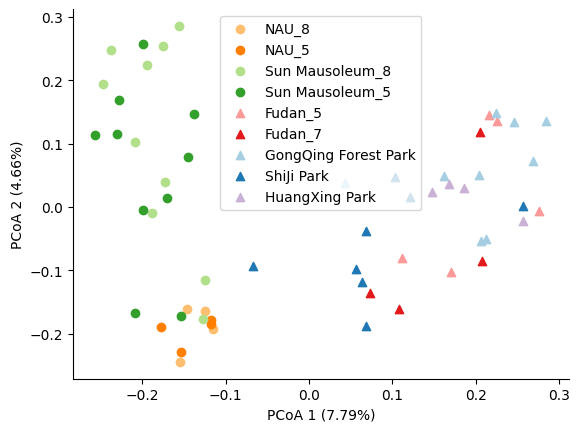

In [31]:
fig, ax = plt.subplots()
ax.scatter(pc1_cpsnj1, pc2_cpsnj1,c='#fdbf6f', label='NAU_8')
ax.scatter(pc1_snj1, pc2_snj1,c='#ff7f00', label='NAU_5')
ax.scatter(pc1_cpsnj2, pc2_cpsnj2,c='#b2df8a',label='Sun Mausoleum_8')
ax.scatter(pc1_snj2, pc2_snj2,c='#33a02c', label='Sun Mausoleum_5')
ax.scatter(pc1_fd5, pc2_fd5,c='#fb9a99',marker='^', label='Fudan_5')
ax.scatter(pc1_fd7, pc2_fd7,c='#e31a1c',marker='^', label='Fudan_7')
ax.scatter(pc1_gq, pc2_gq,c='#a6cee3',marker='^', label='GongQing Forest Park')
ax.scatter(pc1_sj, pc2_sj,c='#1f78b4',marker='^', label='ShiJi Park')
ax.scatter(pc1_hx, pc2_hx,c='#cab2d6',marker='^', label='HuangXing Park')
plt.legend()
ax.set_xlabel('PCoA 1 (7.79%)')
ax.set_ylabel('PCoA 2 (4.66%)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('/mnt/d/soil/manuscript/draft/mine/pcoa_jaccard.svg')

In [15]:
otu_tab = pd.read_csv('../pre-calculated_data/all_otu_table.S3.5.rib_prot_S2_rpsB.ebd', sep='\t', index_col=0)
otu_tab

,AAAAAAAACGCGAACCGCTACGCCCGCAAGGTCGGATTTACGTCGGTGGCGTTGATCGAC,AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAAAAGAACGCCATCAGCGAATCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAAAAGAACGCCGTGAAAGAAGCCCGCAAGCTGGGCATCGCCACGGTGGCGCTCATCGAC,AAAAAGATAGCCAACAAAGAAGCGCACCGGCTCAAAAAAAACGTCGCGGCAATCGTCCAA,AAAAATATTGCATTGAAAGAAGCGCAGAGATTAAACGTAAACACTTTTGGAATTGTTGAT,AAAAATGGGGCGCTCGCGGAAGCGAAGCGACTCGGCATTCCGATCGTTGGCATCGTCGAT,AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,AAACACAACGCCGTTGCTGAGGCGCGTCGGCTCAAAATCCCGGTCGTCGCGATAGTGGAT,AAACACAACGCGGTGAAGGAAGCCCGCCGCCTGTCGATCCCGGTCATCGCCATGCTCGAC,...,TGCGCAGTTCGTATCGACGACTGCAACGACAGGAATACCGAGCTTCTTGGCTTCGTGAAT,TGGAGAATCTGTGTCACAGAGAGCAATAACGGGAATGTTGACGTAGCTGGCCTCCTTGAT,TGGCACCTGGCGGTCGAGGAGGCCCGCAAGCTGCGGATCCCGATCATCGGCATCCTCGAC,TGTGAAAATGTTTCAGATGAATTTGCTTCAGCTAACATTCCAACTATAGGAATTGTTGAC,TTCAGAGAAGTTGTATCTGAAGCTTATGATATGGAGATTCCAGTTGTTGCGGCAATGGAT,TTGAAGATCTCGATAATGGTTGGCCGGGCACTCCGCATAAAAACAGTCTCGATGATCGAC,TTGAATATCGCATTCACAGAAGCAATACGGCTGGGTATGGGTACTTTCGGGATGGTGGAG,TTGCGCATCGCGGTCAGCGAGGCGAACAAGCTGGGCATCCCGATCGTCGCTATGGTGGAC,TTTGCTGCAGCGATAAAAGAGGCTTCATCCTTGAGTATTCCATCGTTAGGATTGATGGAT,TTTTATTCGTGTTTTTTTGAATCGACTTATTGTGGAATTCCGGCTATTGGTATGATTGAT
CPSNJ01_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ02_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ03_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ04_350,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ08_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ09_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ10_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ11_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ13_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ14_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
otus_rows = otu_tab.index.tolist()
otus_rows

['CPSNJ01_350',
 'CPSNJ02_350',
 'CPSNJ03_350',
 'CPSNJ04_350',
 'CPSNJ08_350',
 'CPSNJ09_350',
 'CPSNJ10_350',
 'CPSNJ11_350',
 'CPSNJ13_350',
 'CPSNJ14_350',
 'CPSNJ15_350',
 'CPSNJ16_350',
 'CPSNJ19_350',
 'CPSNJ20_350',
 '10_350',
 '11_350',
 '12_350',
 '13_350',
 '14_350',
 '15_350',
 '16_350',
 '17_350',
 '18_350',
 '19_350',
 '1_350',
 '20_350',
 '21_350',
 '22_350',
 '23_350',
 '24_350',
 '25_350',
 '26_350',
 '27_350',
 '28_350',
 '29_350',
 '2_350',
 '30_350',
 '3_350',
 '4_350',
 '5_350',
 '6_350',
 '7_350',
 '8_350',
 '9_350',
 'SNJ01_350',
 'SNJ02_350',
 'SNJ03_350',
 'SNJ04_350',
 'SNJ08_350',
 'SNJ09_350',
 'SNJ10_350',
 'SNJ11_350',
 'SNJ13_350',
 'SNJ14_350',
 'SNJ15_350',
 'SNJ16_350',
 'SNJ19_350',
 'SNJ20_350']

In [19]:
bc_div = beta_diversity('braycurtis', otu_tab, ids=otus_rows, validate=True)
bc_pcoa = pcoa(bc_div)

In [20]:
df = bc_pcoa.samples
pc1_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC1']
pc2_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC2']
pc1_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC1']
pc2_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC2']
pc1_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC1']
pc2_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC2']
pc2_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC2']
pc1_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC1']
pc1_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC1']
pc2_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC2']
pc1_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC1']
pc2_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC2']
pc1_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC1']
pc2_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC2']
pc1_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC1']
pc2_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC2']
pc1_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC1']
pc2_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC2']
bc_pcoa.proportion_explained

PC1     0.083077
PC2     0.045801
PC3     0.035790
PC4     0.031727
PC5     0.029224
PC6     0.023986
PC7     0.023003
PC8     0.021812
PC9     0.021437
PC10    0.020310
PC11    0.020007
PC12    0.018927
PC13    0.018403
PC14    0.017826
PC15    0.017710
PC16    0.017688
PC17    0.017217
PC18    0.016840
PC19    0.016608
PC20    0.016438
PC21    0.016168
PC22    0.015962
PC23    0.015588
PC24    0.015484
PC25    0.015221
PC26    0.015093
PC27    0.014872
PC28    0.014767
PC29    0.014576
PC30    0.014529
PC31    0.014289
PC32    0.014119
PC33    0.013968
PC34    0.013873
PC35    0.013685
PC36    0.013624
PC37    0.013431
PC38    0.013318
PC39    0.013161
PC40    0.012992
PC41    0.012816
PC42    0.012736
PC43    0.012703
PC44    0.012528
PC45    0.012151
PC46    0.012001
PC47    0.011974
PC48    0.011848
PC49    0.011653
PC50    0.011503
PC51    0.011369
PC52    0.011161
PC53    0.010921
PC54    0.010888
PC55    0.010759
PC56    0.010489
PC57    0.009948
PC58    0.000000
dtype: float64

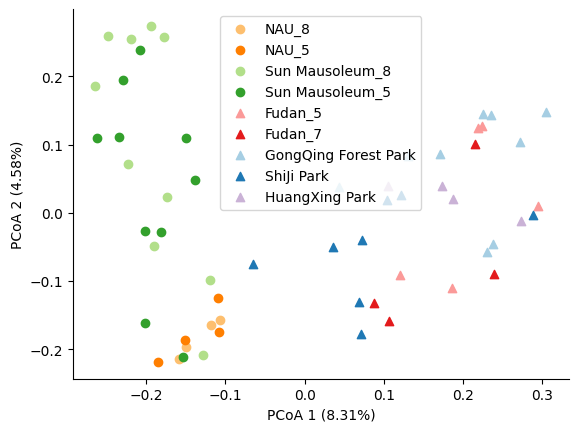

In [23]:
fig, ax = plt.subplots()
ax.scatter(pc1_cpsnj1, pc2_cpsnj1,c='#fdbf6f', label='NAU_8')
ax.scatter(pc1_snj1, pc2_snj1,c='#ff7f00', label='NAU_5')
ax.scatter(pc1_cpsnj2, pc2_cpsnj2,c='#b2df8a',label='Sun Mausoleum_8')
ax.scatter(pc1_snj2, pc2_snj2,c='#33a02c', label='Sun Mausoleum_5')
ax.scatter(pc1_fd5, pc2_fd5,c='#fb9a99',marker='^', label='Fudan_5')
ax.scatter(pc1_fd7, pc2_fd7,c='#e31a1c',marker='^', label='Fudan_7')
ax.scatter(pc1_gq, pc2_gq,c='#a6cee3',marker='^', label='GongQing Forest Park')
ax.scatter(pc1_sj, pc2_sj,c='#1f78b4',marker='^', label='ShiJi Park')
ax.scatter(pc1_hx, pc2_hx,c='#cab2d6',marker='^', label='HuangXing Park')
plt.legend()
ax.set_xlabel('PCoA 1 (8.31%)')
ax.set_ylabel('PCoA 2 (4.58%)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('/mnt/d/soil/manuscript/draft/mine/pcoa_bc_nolog_nofilter.svg')

In [55]:
otu_tab = pd.read_csv('../pre-calculated_data/all_otu_table.S3.5.rib_prot_S2_rpsB.ebd', sep='\t', index_col=0)
otu_tab

,AAAAAAAACGCGAACCGCTACGCCCGCAAGGTCGGATTTACGTCGGTGGCGTTGATCGAC,AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAAAAGAACGCCATCAGCGAATCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAAAAGAACGCCGTGAAAGAAGCCCGCAAGCTGGGCATCGCCACGGTGGCGCTCATCGAC,AAAAAGATAGCCAACAAAGAAGCGCACCGGCTCAAAAAAAACGTCGCGGCAATCGTCCAA,AAAAATATTGCATTGAAAGAAGCGCAGAGATTAAACGTAAACACTTTTGGAATTGTTGAT,AAAAATGGGGCGCTCGCGGAAGCGAAGCGACTCGGCATTCCGATCGTTGGCATCGTCGAT,AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,AAACACAACGCCGTTGCTGAGGCGCGTCGGCTCAAAATCCCGGTCGTCGCGATAGTGGAT,AAACACAACGCGGTGAAGGAAGCCCGCCGCCTGTCGATCCCGGTCATCGCCATGCTCGAC,...,TGCGCAGTTCGTATCGACGACTGCAACGACAGGAATACCGAGCTTCTTGGCTTCGTGAAT,TGGAGAATCTGTGTCACAGAGAGCAATAACGGGAATGTTGACGTAGCTGGCCTCCTTGAT,TGGCACCTGGCGGTCGAGGAGGCCCGCAAGCTGCGGATCCCGATCATCGGCATCCTCGAC,TGTGAAAATGTTTCAGATGAATTTGCTTCAGCTAACATTCCAACTATAGGAATTGTTGAC,TTCAGAGAAGTTGTATCTGAAGCTTATGATATGGAGATTCCAGTTGTTGCGGCAATGGAT,TTGAAGATCTCGATAATGGTTGGCCGGGCACTCCGCATAAAAACAGTCTCGATGATCGAC,TTGAATATCGCATTCACAGAAGCAATACGGCTGGGTATGGGTACTTTCGGGATGGTGGAG,TTGCGCATCGCGGTCAGCGAGGCGAACAAGCTGGGCATCCCGATCGTCGCTATGGTGGAC,TTTGCTGCAGCGATAAAAGAGGCTTCATCCTTGAGTATTCCATCGTTAGGATTGATGGAT,TTTTATTCGTGTTTTTTTGAATCGACTTATTGTGGAATTCCGGCTATTGGTATGATTGAT
CPSNJ01_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ02_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ03_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ04_350,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ08_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ09_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ10_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ11_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ13_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ14_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
bc_div = beta_diversity('canberra', otu_tab, ids=otus_rows, validate=True)
bc_pcoa = pcoa(bc_div)

/home/huayuqin/miniconda3/envs/soil/lib/python3.11/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:143: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -5.78263340656905e-08 and the largest is 40275681.754657626.
  warn(


In [57]:
metadata = pd.read_csv('../pre-calculated_data/metadata_otu.csv', index_col='Sample')
metadata.loc[metadata['Site'].str.startswith('NanJing'), 'Site'] = 'NanJing'
metadata.loc[metadata['Site'].str.startswith('ShangHai'), 'Site'] = 'ShangHai'
results = anosim(bc_div, metadata, column='Site', permutations=999)
results

method name                 ANOSIM
test statistic name              R
sample size                     58
number of groups                 2
test statistic            0.273812
p-value                      0.001
number of permutations         999
Name: ANOSIM results, dtype: object

In [58]:
df = bc_pcoa.samples
pc1_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC1']
pc2_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC2']
pc1_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC1']
pc2_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC2']
pc1_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC1']
pc2_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC2']
pc2_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC2']
pc1_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC1']
pc1_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC1']
pc2_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC2']
pc1_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC1']
pc2_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC2']
pc1_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC1']
pc2_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC2']
pc1_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC1']
pc2_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC2']
pc1_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC1']
pc2_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC2']
bc_pcoa.proportion_explained

PC1     0.066835
PC2     0.041971
PC3     0.032958
PC4     0.030164
PC5     0.027779
PC6     0.026023
PC7     0.025096
PC8     0.023491
PC9     0.023316
PC10    0.022941
PC11    0.022228
PC12    0.021638
PC13    0.021173
PC14    0.020028
PC15    0.019616
PC16    0.019087
PC17    0.018941
PC18    0.018130
PC19    0.017830
PC20    0.017752
PC21    0.017498
PC22    0.017325
PC23    0.017053
PC24    0.016749
PC25    0.016606
PC26    0.016265
PC27    0.015910
PC28    0.015688
PC29    0.015511
PC30    0.015175
PC31    0.015057
PC32    0.014815
PC33    0.014511
PC34    0.014404
PC35    0.014148
PC36    0.014079
PC37    0.013807
PC38    0.013586
PC39    0.013394
PC40    0.013338
PC41    0.013049
PC42    0.012840
PC43    0.012573
PC44    0.012036
PC45    0.011518
PC46    0.011326
PC47    0.010977
PC48    0.010817
PC49    0.010289
PC50    0.010104
PC51    0.009899
PC52    0.009646
PC53    0.009435
PC54    0.009028
PC55    0.008592
PC56    0.008545
PC57    0.007414
PC58    0.000000
dtype: float64

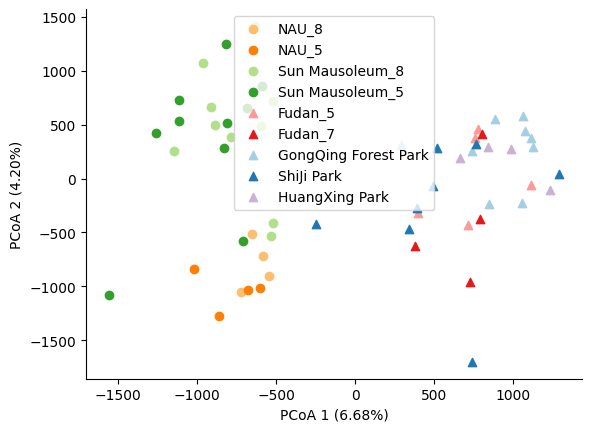

In [60]:
fig, ax = plt.subplots()
ax.scatter(pc1_cpsnj1, pc2_cpsnj1,c='#fdbf6f', label='NAU_8')
ax.scatter(pc1_snj1, pc2_snj1,c='#ff7f00', label='NAU_5')
ax.scatter(pc1_cpsnj2, pc2_cpsnj2,c='#b2df8a',label='Sun Mausoleum_8')
ax.scatter(pc1_snj2, pc2_snj2,c='#33a02c', label='Sun Mausoleum_5')
ax.scatter(pc1_fd5, pc2_fd5,c='#fb9a99',marker='^', label='Fudan_5')
ax.scatter(pc1_fd7, pc2_fd7,c='#e31a1c',marker='^', label='Fudan_7')
ax.scatter(pc1_gq, pc2_gq,c='#a6cee3',marker='^', label='GongQing Forest Park')
ax.scatter(pc1_sj, pc2_sj,c='#1f78b4',marker='^', label='ShiJi Park')
ax.scatter(pc1_hx, pc2_hx,c='#cab2d6',marker='^', label='HuangXing Park')
plt.legend()
ax.set_xlabel('PCoA 1 (6.68%)')
ax.set_ylabel('PCoA 2 (4.20%)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('/mnt/d/soil/manuscript/draft/mine/pcoa_canberra_nolog_nofilter.svg')

In [62]:
otu_tab = pd.read_csv('../pre-calculated_data/all_otu_table.S3.5.rib_prot_S2_rpsB.ebd', sep='\t', index_col=0)
otu_tab = otu_tab.T
otu_tab

,CPSNJ01_350,CPSNJ02_350,CPSNJ03_350,CPSNJ04_350,CPSNJ08_350,CPSNJ09_350,CPSNJ10_350,CPSNJ11_350,CPSNJ13_350,CPSNJ14_350,...,SNJ08_350,SNJ09_350,SNJ10_350,SNJ11_350,SNJ13_350,SNJ14_350,SNJ15_350,SNJ16_350,SNJ19_350,SNJ20_350
AAAAAAAACGCGAACCGCTACGCCCGCAAGGTCGGATTTACGTCGGTGGCGTTGATCGAC,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAAAGAACGCCATCAGCGAATCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAAAGAACGCCGTGAAAGAAGCCCGCAAGCTGGGCATCGCCACGGTGGCGCTCATCGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAAAGATAGCCAACAAAGAAGCGCACCGGCTCAAAAAAAACGTCGCGGCAATCGTCCAA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGAAGATCTCGATAATGGTTGGCCGGGCACTCCGCATAAAAACAGTCTCGATGATCGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
TTGAATATCGCATTCACAGAAGCAATACGGCTGGGTATGGGTACTTTCGGGATGGTGGAG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTGCGCATCGCGGTCAGCGAGGCGAACAAGCTGGGCATCCCGATCGTCGCTATGGTGGAC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGCTGCAGCGATAAAAGAGGCTTCATCCTTGAGTATTCCATCGTTAGGATTGATGGAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [63]:
otus_RA_filt_zoom = otus_RA_filt * 1000000
np.set_printoptions(precision=5)
otus_np = otus_RA_filt_zoom.to_numpy()

minval = np.min(otus_np[np.nonzero(otus_np)])
pseudo = minval/2
otus_RA_filt_zoom.replace([0],pseudo, inplace=True)

otus_RA_filt_zoom = otus_RA_filt_zoom.T
otus_RA_filt_zoom

,AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,AACCACACCCTGCTGCACGAGTGCGGCCTCGCCTCCATCCCAACCATCGGCGTCATCGAC,AACCAGATTGCCATCAAGGAGGCCACCAAGTTCCACATCCCCACCATCGGCATCACAGAC,AACTACACCCTCTTGTATGAGTGTGCATTAGCTACCATCCCCACCATTGGCGTCATTGAC,AATTATATAATATGTAATGAGGCTATATCTATGTTTTTGCCTATTATTGCAATAGTTGAC,AATTATATAGTTTTAAAAGAAGCCGCTTTAATGTTTATGCCTGTTATAGGTATTATTGAT,ACACATCCAGCAGTCGTCGATTCGGCTAAACTCCTGATCCCGACCGTCGGTATTGTTGAC,AGAACAATTTGTGTCGACGACTGCAACGATGGGGATGCCCAGACGATTAGCTTCAGCGAC,AGCGCCAACGCCGTGCGCGAAGCCCGTAAAATGCGCTTGCCAATCGTAGCCGTTGTCGAC,...,GTCGGCGTTGGTGTCCACGATGCCAACGATGGGGATGCCGAGACGGTTGGCTTCCTTGAC,GTGAAGAACGCCGCGAAGCAGGCCGCCGACGCCGGCATCCCCATCGTCTCCATCGAGGGC,GTTAGCGTTAGTGTCAACGAGACCAACAACAGGCACACCAAGTGTCTTTGCTTCCTTAAC,GTTGCAGTTGGTATCGACGAGTGCAACGATCGGGATATTGAGCAGGTTTGCTTCGTGGAC,GTTGCAGTTGGTATCGACGATGGCCACGGTGGTAATGCCCAGCTTGTTTGCTTCGTGAAC,GTTGCTGTTGGTATCGACAACGCCGATGACCGGAATACCCAGCTTGTTGGCTTCCTGGAT,GTTGGCGTTCGTATCCACAATGCCCATCACAGGGATGCGCAGTGTGTTGGCTTCTTTGAC,TACCACGCTGCCGTCCGCGAGGCGGTGCGTGCTGGCGTGCCCATCATCGCGTTTGCAAAC,TGAACAGTTGGTGTCAACGACGGCAACGATGGGGATATCAAGCCTGTTGGCTTCTTTGAT,TGAACAGTTTGTATCGACCACTGCAAAAACCGGAATGCCGAGCTTGTTGGCTTCAGCGAC
CPSNJ01_350,85.587128,85.587128,85.587128,85.587128,85.587128,886.328385,85.587128,85.587128,221.582096,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ02_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,501.253133,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ03_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ04_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ08_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ09_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ10_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ11_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ13_350,85.587128,808.843354,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128
CPSNJ14_350,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,...,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128,85.587128


In [64]:
np.set_printoptions(precision=5)
otus_rows = otus_RA_filt_zoom.index.tolist()
otus_cols = otus_RA_filt_zoom.columns.tolist()
otus_np = otus_RA_filt_zoom.to_numpy()

log_otus_tab = np.log10(otus_np)
otus_tab_F = pd.DataFrame(log_otus_tab, columns=otus_cols, index=otus_rows)
otus_tab_F

,AAAAAGAACGCCATCAGCGAAGCTCAAAAGCTGGGCGTCGCGACGGTCGCATTGATCGAC,AAACAAAATGCGGTCAACGAGGCGCGACGTCTTGGCATTCCAGTCGTCGCGATCGTCGAT,AACCACACCCTGCTGCACGAGTGCGGCCTCGCCTCCATCCCAACCATCGGCGTCATCGAC,AACCAGATTGCCATCAAGGAGGCCACCAAGTTCCACATCCCCACCATCGGCATCACAGAC,AACTACACCCTCTTGTATGAGTGTGCATTAGCTACCATCCCCACCATTGGCGTCATTGAC,AATTATATAATATGTAATGAGGCTATATCTATGTTTTTGCCTATTATTGCAATAGTTGAC,AATTATATAGTTTTAAAAGAAGCCGCTTTAATGTTTATGCCTGTTATAGGTATTATTGAT,ACACATCCAGCAGTCGTCGATTCGGCTAAACTCCTGATCCCGACCGTCGGTATTGTTGAC,AGAACAATTTGTGTCGACGACTGCAACGATGGGGATGCCCAGACGATTAGCTTCAGCGAC,AGCGCCAACGCCGTGCGCGAAGCCCGTAAAATGCGCTTGCCAATCGTAGCCGTTGTCGAC,...,GTCGGCGTTGGTGTCCACGATGCCAACGATGGGGATGCCGAGACGGTTGGCTTCCTTGAC,GTGAAGAACGCCGCGAAGCAGGCCGCCGACGCCGGCATCCCCATCGTCTCCATCGAGGGC,GTTAGCGTTAGTGTCAACGAGACCAACAACAGGCACACCAAGTGTCTTTGCTTCCTTAAC,GTTGCAGTTGGTATCGACGAGTGCAACGATCGGGATATTGAGCAGGTTTGCTTCGTGGAC,GTTGCAGTTGGTATCGACGATGGCCACGGTGGTAATGCCCAGCTTGTTTGCTTCGTGAAC,GTTGCTGTTGGTATCGACAACGCCGATGACCGGAATACCCAGCTTGTTGGCTTCCTGGAT,GTTGGCGTTCGTATCCACAATGCCCATCACAGGGATGCGCAGTGTGTTGGCTTCTTTGAC,TACCACGCTGCCGTCCGCGAGGCGGTGCGTGCTGGCGTGCCCATCATCGCGTTTGCAAAC,TGAACAGTTGGTGTCAACGACGGCAACGATGGGGATATCAAGCCTGTTGGCTTCTTTGAT,TGAACAGTTTGTATCGACCACTGCAAAAACCGGAATGCCGAGCTTGTTGGCTTCAGCGAC
CPSNJ01_350,1.932408,1.932408,1.932408,1.932408,1.932408,2.947595,1.932408,1.932408,2.345535,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ02_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,2.700057,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ03_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ04_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ08_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ09_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ10_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ11_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ13_350,1.932408,2.907864,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408
CPSNJ14_350,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,...,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408,1.932408


In [65]:
bc_div = beta_diversity('canberra', log_otus_tab, ids=otus_rows, validate=True)
bc_pcoa = pcoa(bc_div)

In [66]:
metadata = pd.read_csv('../pre-calculated_data/metadata_otu.csv', index_col='Sample')
metadata.loc[metadata['Site'].str.startswith('NanJing'), 'Site'] = 'NanJing'
metadata.loc[metadata['Site'].str.startswith('ShangHai'), 'Site'] = 'ShangHai'
results = anosim(bc_div, metadata, column='Site', permutations=999)
results

method name                 ANOSIM
test statistic name              R
sample size                     58
number of groups                 2
test statistic            0.753049
p-value                      0.001
number of permutations         999
Name: ANOSIM results, dtype: object

In [67]:
df = bc_pcoa.samples
pc1_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC1']
pc2_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC2']
pc1_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC1']
pc2_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC2']
pc1_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC1']
pc2_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC2']
pc2_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC2']
pc1_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC1']
pc1_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC1']
pc2_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC2']
pc1_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC1']
pc2_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC2']
pc1_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC1']
pc2_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC2']
pc1_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC1']
pc2_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC2']
pc1_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC1']
pc2_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC2']
bc_pcoa.proportion_explained

PC1     0.119568
PC2     0.061517
PC3     0.042745
PC4     0.037809
PC5     0.033372
PC6     0.025544
PC7     0.024867
PC8     0.023506
PC9     0.021209
PC10    0.020142
PC11    0.019967
PC12    0.018680
PC13    0.018326
PC14    0.017812
PC15    0.017006
PC16    0.016779
PC17    0.016266
PC18    0.015979
PC19    0.015817
PC20    0.015328
PC21    0.014980
PC22    0.014712
PC23    0.014502
PC24    0.014330
PC25    0.013951
PC26    0.013697
PC27    0.013447
PC28    0.013248
PC29    0.013146
PC30    0.013141
PC31    0.012981
PC32    0.012670
PC33    0.012496
PC34    0.012182
PC35    0.012136
PC36    0.012021
PC37    0.011870
PC38    0.011527
PC39    0.011410
PC40    0.011138
PC41    0.011060
PC42    0.010866
PC43    0.010569
PC44    0.010339
PC45    0.010049
PC46    0.009882
PC47    0.009463
PC48    0.009336
PC49    0.009101
PC50    0.009080
PC51    0.008855
PC52    0.008689
PC53    0.008579
PC54    0.008271
PC55    0.008158
PC56    0.008014
PC57    0.007864
PC58    0.000000
dtype: float64

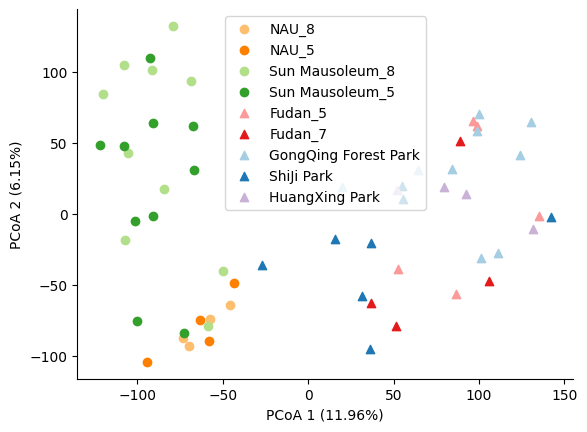

In [69]:
fig, ax = plt.subplots()
ax.scatter(pc1_cpsnj1, pc2_cpsnj1,c='#fdbf6f', label='NAU_8')
ax.scatter(pc1_snj1, pc2_snj1,c='#ff7f00', label='NAU_5')
ax.scatter(pc1_cpsnj2, pc2_cpsnj2,c='#b2df8a', label='Sun Mausoleum_8')
ax.scatter(pc1_snj2, pc2_snj2,c='#33a02c', label='Sun Mausoleum_5')
ax.scatter(pc1_fd5, pc2_fd5,c='#fb9a99',marker='^', label='Fudan_5')
ax.scatter(pc1_fd7, pc2_fd7,c='#e31a1c',marker='^', label='Fudan_7')
ax.scatter(pc1_gq, pc2_gq,c='#a6cee3',marker='^', label='GongQing Forest Park')
ax.scatter(pc1_sj, pc2_sj,c='#1f78b4',marker='^', label='ShiJi Park')
ax.scatter(pc1_hx, pc2_hx,c='#cab2d6',marker='^', label='HuangXing Park')
plt.legend()
ax.set_xlabel('PCoA 1 (11.96%)')
ax.set_ylabel('PCoA 2 (6.15%)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('/mnt/d/soil/manuscript/draft/mine/pcoa_canberra_nofilter.svg')

In [72]:
otu_tab = pd.read_csv('/mnt/d/soil/profile/otu/all_otu_table.S3.42.RNA_pol_A_bac.ebd', sep='\t', index_col=0)
otu_tab

,AAAAAAAGAATTATTGATTTAATTAATCTTTCTGAAGAAGAAGGATTAAAAATAAAAAAT,AAAAAATACAACGGCGACCTGGTGAAGCGCACCGAAGTCCAGCTGCTGCGCACGCCGAAC,AAAAAGCATTTTGGCGAAGTCGTGTTACTTAAGGAGGCGGACTTATATCGGGTTCAAAAT,AAAAAGCTTATTATAGATCTTATTAATCTCGAAGAATATGGGTTGATACAAATTAAGAAT,AAAAAGTATTTCGGCGAAGTCGTCTTACTTAAGGAGCTGGACTTATATCGGGTTCAAAAT,AAAAAGTATTTCGGCGAGATCATCTTTCTCAGAGAGGCCGACTTATATCGGGTTCAAAAT,AAAATTTACATTGGTGATTTGATTCAACGTACTGAGAATGAGCTATTAAAGGCGCCAAAC,AAACAGACCATCGGCGATCACGCCTCGAGCACGGAAGCGGAGCTGATGGGCGTCAAGAAC,AAACCGCTTATCGGCGAGCTCGTGCAGCGCACCGAAGGCGAGATGCTCAAGACCAAGAAC,AAACGCACCCTCGGCGACCTGCTCCGCATCACCCACGCCGAGCTGCTGAGCAACAACAAC,...,TTTGCCACGCTCGGCGACTTTCAGGGTAAAAGCAAAACTGATCTAGAGAAGGTCCGAAAT,TTTGCCAGCGCTGGTGATCTGGTAGAACAGGGTGATCAGCCTCTACTGGACATTAAGGGC,TTTGCTACCCTTGCTGATTTTGAAGGCAAATCACGATCAGACATTGAAAAAGTCCGCAAT,TTTGGAGTAGTTAAGGACTTGGTAGAAGCCAAGAAATCGGAGATCTCTAAAATCAAGAAT,TTTGGGTCAGCACTCGATGTCGCGACCGCAACTCGCTCGGAACTCTTGCATCAGAAGAAC,TTTGTCAGCGCGAGCGATGTAGTCGAGCAGGGTGATCAGCCCCTGTTGGACATCAAGGGC,TTTGTTACTGTTGAAGATGTACTTCAGCACAGTGAAGCTGAACTGCTGTGCGTGGAAAAT,TTTTATTATGTCGGTGACTTAGTACAGATGAGCGAAGCCGAACTTTTGCGCCTTCCGGGT,TTTTCAAAGCTCAAACAATTAACCGAAGTCACCGAAGCCGAATTAAGCAAATTGCATGGT,TTTTCCACTATCGGAGATATTGTTAGAGGTGGAAGAACTGAGATAAACAAACTGCGTAAT
CPSNJ01_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ02_350,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ03_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ04_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ08_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ09_350,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
CPSNJ10_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
CPSNJ11_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
CPSNJ13_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
CPSNJ14_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [73]:
#remove samples (<100 total count OTUs)
otus_filt = otu_tab[otu_tab.sum(axis=1) >= 100]
otus_filt_wo0 = otus_filt[otus_filt.sum(axis=1) > 0]
otus_filt_wo0 = otus_filt_wo0.loc[:,otus_filt_wo0.sum(axis=0) > 0]

otus_filt_wo0['Sum'] = otus_filt_wo0.sum(axis=1)
otus_RA = otus_filt_wo0.iloc[:, :].div(otus_filt_wo0.Sum, axis=0)
otus_RA = otus_RA.drop(['Sum'], axis=1)

#remove low RA
otus_RA = otus_RA.T
otus_RA['Mean'] = otus_RA.mean(axis=1)
otus_RA_filt = otus_RA.loc[otus_RA['Mean'].between(0.00001, 1)]
otus_RA_filt = otus_RA_filt.drop(['Mean'], axis=1)
otus_RA_filt 

,CPSNJ01_350,CPSNJ02_350,CPSNJ03_350,CPSNJ04_350,CPSNJ08_350,CPSNJ09_350,CPSNJ10_350,CPSNJ11_350,CPSNJ13_350,CPSNJ14_350,...,SNJ08_350,SNJ09_350,SNJ10_350,SNJ11_350,SNJ13_350,SNJ14_350,SNJ15_350,SNJ16_350,SNJ19_350,SNJ20_350
ACCAGGACGATCCGCGAGCTCGTGCAGAAGACCGAAGCCGAGATGCTCAAGACCAAGAAC,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000644,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.00000,0.0
ACCATCTACATCGGCGATCTGGTGCAGAAGACCGAGGCGGAGATGCTGCGCACGCCGAAC,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000227,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.00000,0.0
ACCGTCACCGTCGGCGACCTCCTGAACTACACCGAAGCCGACCTCCTGAAGAGCAAGAAC,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.00000,0.0
ACCGTCACCGTCGGCGACCTCTTGAACTACACGGAAGCCGATCTCCTGAAGAGCAAGAAC,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000718,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000227,0.000443,0.0,0.00000,0.0
ACCTTCACGGTCCGCGACCTCCTCAACAGCACGCCCGAGCAGCTCCTCTCGATCGCCAAC,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.00068,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGAAACAGTAGAAAAGCTTGTTAACGCAAAAAAGGAAGATCTTATTAAAGTTAGAAAC,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.00000,0.0
TTTGAAACAGTTGGTGATGCTATGAAAGTAAGTGATTATGAGTTACTTAGGATACCCAAT,0.0,0.0,0.0,0.0,0.000174,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000458,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.00000,0.0
TTTGACACAGTTGAAAGACTTGCTAACGCTCCAAAAGAAGAACTATTAAAAGTTCGTAAC,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.00000,0.0
TTTGATACTATTACCAAGCTTATCGAAACCCCCAAAGCCGAACTAGCCAAAGTCAAAAAT,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000683,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.00000,0.0


In [74]:
otus_RA_filt_zoom = otus_RA_filt * 1000000
np.set_printoptions(precision=5)
otus_np = otus_RA_filt_zoom.to_numpy()

minval = np.min(otus_np[np.nonzero(otus_np)])
pseudo = minval/2
otus_RA_filt_zoom.replace([0],pseudo, inplace=True)

otus_RA_filt_zoom = otus_RA_filt_zoom.T
otus_RA_filt_zoom

,ACCAGGACGATCCGCGAGCTCGTGCAGAAGACCGAAGCCGAGATGCTCAAGACCAAGAAC,ACCATCTACATCGGCGATCTGGTGCAGAAGACCGAGGCGGAGATGCTGCGCACGCCGAAC,ACCGTCACCGTCGGCGACCTCCTGAACTACACCGAAGCCGACCTCCTGAAGAGCAAGAAC,ACCGTCACCGTCGGCGACCTCTTGAACTACACGGAAGCCGATCTCCTGAAGAGCAAGAAC,ACCTTCACGGTCCGCGACCTCCTCAACAGCACGCCCGAGCAGCTCCTCTCGATCGCCAAC,ACGAGCACAATCGGCGAATTGCTCCGCAAGACGGGCGACGATCTTTTGGAATGTAAGAAC,ACGCAGACGGTCGGCCAGCTCTGCGAAGTCAGCGAGGAGCAGCTCCTCGCCTGCAAGAAC,AGCGAGCACTTCCTTGATCTCGTTGAGCGACTTGCGGCCGAGGTTCGGCGTCTTCAGCAG,AGCGAGCACTTCCTTGATCTCGTTGAGCGACTTGCGGCCGAGGTTCGGCGTCTTGAGGAG,AGCGAGTACTTCCTTGATCTCGTTGAGCGACTTGCGGCCGAGGTTGGGCGTCTTCAGGAG,...,TTGTTGACGCTTCGAGCGCTCGCCACGGCGACGGAAAGCGATTTGACGAGCATCCGCGGC,TTTACGGAGCTCAAGCAGTTGACGAAGGCGACCGAAGCCGAATTAATGGCCCTCCATGGC,TTTATTACCGTAGAGGAAGTGCTTCAGTACACTGAATCCGAATTGCTGTGTGTGGAAAAT,TTTCGTCAATTGACCGATATCTGCCTGTTGTCGCGCGATGACCTGCTGTGCGTCCAGCGG,TTTCGTGTCGTCGGCGATCTCGTTCATCGATCCGAATCCGAGATCTTGACGATGCAGGGA,TTTGAAACAGTAGAAAAGCTTGTTAACGCAAAAAAGGAAGATCTTATTAAAGTTAGAAAC,TTTGAAACAGTTGGTGATGCTATGAAAGTAAGTGATTATGAGTTACTTAGGATACCCAAT,TTTGACACAGTTGAAAGACTTGCTAACGCTCCAAAAGAAGAACTATTAAAAGTTCGTAAC,TTTGATACTATTACCAAGCTTATCGAAACCCCCAAAGCCGAACTAGCCAAAGTCAAAAAT,TTTGTTACTGTTGAAGATGTACTTCAGCACAGTGAAGCTGAACTGCTGTGCGTGGAAAAT
CPSNJ01_350,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,...,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431
CPSNJ02_350,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,...,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431
CPSNJ03_350,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,...,84.402431,84.402431,967.819985,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431
CPSNJ04_350,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,...,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431
CPSNJ08_350,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,173.973556,84.402431,84.402431,84.402431,...,84.402431,84.402431,84.402431,84.402431,173.973556,84.402431,173.973556,84.402431,84.402431,84.402431
CPSNJ09_350,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,...,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,255.950857
CPSNJ10_350,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,...,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,356.442702
CPSNJ11_350,644.329897,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,...,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,214.776632
CPSNJ13_350,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,...,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,682.749203,84.402431
CPSNJ14_350,84.402431,84.402431,84.402431,717.617510,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,...,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431,84.402431


In [75]:
np.set_printoptions(precision=5)
otus_rows = otus_RA_filt_zoom.index.tolist()
otus_cols = otus_RA_filt_zoom.columns.tolist()
otus_np = otus_RA_filt_zoom.to_numpy()

log_otus_tab = np.log10(otus_np)
otus_tab_F = pd.DataFrame(log_otus_tab, columns=otus_cols, index=otus_rows)
otus_tab_F

,ACCAGGACGATCCGCGAGCTCGTGCAGAAGACCGAAGCCGAGATGCTCAAGACCAAGAAC,ACCATCTACATCGGCGATCTGGTGCAGAAGACCGAGGCGGAGATGCTGCGCACGCCGAAC,ACCGTCACCGTCGGCGACCTCCTGAACTACACCGAAGCCGACCTCCTGAAGAGCAAGAAC,ACCGTCACCGTCGGCGACCTCTTGAACTACACGGAAGCCGATCTCCTGAAGAGCAAGAAC,ACCTTCACGGTCCGCGACCTCCTCAACAGCACGCCCGAGCAGCTCCTCTCGATCGCCAAC,ACGAGCACAATCGGCGAATTGCTCCGCAAGACGGGCGACGATCTTTTGGAATGTAAGAAC,ACGCAGACGGTCGGCCAGCTCTGCGAAGTCAGCGAGGAGCAGCTCCTCGCCTGCAAGAAC,AGCGAGCACTTCCTTGATCTCGTTGAGCGACTTGCGGCCGAGGTTCGGCGTCTTCAGCAG,AGCGAGCACTTCCTTGATCTCGTTGAGCGACTTGCGGCCGAGGTTCGGCGTCTTGAGGAG,AGCGAGTACTTCCTTGATCTCGTTGAGCGACTTGCGGCCGAGGTTGGGCGTCTTCAGGAG,...,TTGTTGACGCTTCGAGCGCTCGCCACGGCGACGGAAAGCGATTTGACGAGCATCCGCGGC,TTTACGGAGCTCAAGCAGTTGACGAAGGCGACCGAAGCCGAATTAATGGCCCTCCATGGC,TTTATTACCGTAGAGGAAGTGCTTCAGTACACTGAATCCGAATTGCTGTGTGTGGAAAAT,TTTCGTCAATTGACCGATATCTGCCTGTTGTCGCGCGATGACCTGCTGTGCGTCCAGCGG,TTTCGTGTCGTCGGCGATCTCGTTCATCGATCCGAATCCGAGATCTTGACGATGCAGGGA,TTTGAAACAGTAGAAAAGCTTGTTAACGCAAAAAAGGAAGATCTTATTAAAGTTAGAAAC,TTTGAAACAGTTGGTGATGCTATGAAAGTAAGTGATTATGAGTTACTTAGGATACCCAAT,TTTGACACAGTTGAAAGACTTGCTAACGCTCCAAAAGAAGAACTATTAAAAGTTCGTAAC,TTTGATACTATTACCAAGCTTATCGAAACCCCCAAAGCCGAACTAGCCAAAGTCAAAAAT,TTTGTTACTGTTGAAGATGTACTTCAGCACAGTGAAGCTGAACTGCTGTGCGTGGAAAAT
CPSNJ01_350,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,...,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355
CPSNJ02_350,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,...,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355
CPSNJ03_350,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,...,1.926355,1.926355,2.985795,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355
CPSNJ04_350,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,...,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355
CPSNJ08_350,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,2.240483,1.926355,1.926355,1.926355,...,1.926355,1.926355,1.926355,1.926355,2.240483,1.926355,2.240483,1.926355,1.926355,1.926355
CPSNJ09_350,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,...,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,2.408157
CPSNJ10_350,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,...,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,2.551990
CPSNJ11_350,2.809108,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,...,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,2.331987
CPSNJ13_350,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,...,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,2.834261,1.926355
CPSNJ14_350,1.926355,1.926355,1.926355,2.855893,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,...,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355,1.926355


In [76]:
bc_div = beta_diversity('braycurtis', log_otus_tab, ids=otus_rows, validate=True)
bc_pcoa = pcoa(bc_div)

In [77]:
metadata = pd.read_csv('../pre-calculated_data/metadata_otu.csv', index_col='Sample')
metadata.loc[metadata['Site'].str.startswith('NanJing'), 'Site'] = 'NanJing'
metadata.loc[metadata['Site'].str.startswith('ShangHai'), 'Site'] = 'ShangHai'
results = anosim(bc_div, metadata, column='Site', permutations=999)
results

method name                 ANOSIM
test statistic name              R
sample size                     58
number of groups                 2
test statistic            0.691235
p-value                      0.001
number of permutations         999
Name: ANOSIM results, dtype: object

In [78]:
df = bc_pcoa.samples
pc1_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC1']
pc2_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC2']
pc1_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC1']
pc2_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC2']
pc1_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC1']
pc2_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC2']
pc2_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC2']
pc1_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC1']
#pc1_sh = df.loc[df.index.str.match('^\d+' )]['PC1']
#pc2_sh = df.loc[df.index.str.match('^\d+' )]['PC2']
pc1_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC1']
pc2_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC2']
pc1_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC1']
pc2_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC2']
pc1_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC1']
pc2_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC2']
pc1_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC1']
pc2_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC2']
pc1_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC1']
pc2_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC2']
bc_pcoa.proportion_explained

PC1     0.114721
PC2     0.057522
PC3     0.041281
PC4     0.035991
PC5     0.032554
PC6     0.025635
PC7     0.025016
PC8     0.023480
PC9     0.021361
PC10    0.020507
PC11    0.019169
PC12    0.018910
PC13    0.018347
PC14    0.017710
PC15    0.017186
PC16    0.017129
PC17    0.016589
PC18    0.016023
PC19    0.015806
PC20    0.015538
PC21    0.015234
PC22    0.015059
PC23    0.014573
PC24    0.014485
PC25    0.014284
PC26    0.014141
PC27    0.014062
PC28    0.013748
PC29    0.013709
PC30    0.013514
PC31    0.013284
PC32    0.013033
PC33    0.012872
PC34    0.012558
PC35    0.012483
PC36    0.012198
PC37    0.012080
PC38    0.011901
PC39    0.011584
PC40    0.011450
PC41    0.011262
PC42    0.011154
PC43    0.010845
PC44    0.010592
PC45    0.010558
PC46    0.010402
PC47    0.010173
PC48    0.010078
PC49    0.009921
PC50    0.009819
PC51    0.009728
PC52    0.009189
PC53    0.009017
PC54    0.008585
PC55    0.008505
PC56    0.007399
PC57    0.006047
PC58    0.000000
dtype: float64

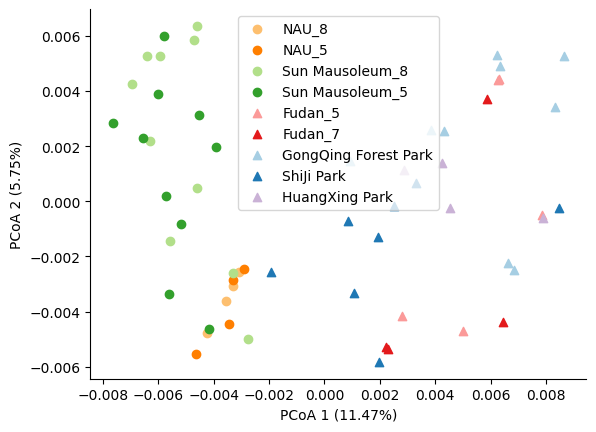

In [81]:
fig, ax = plt.subplots()
ax.scatter(pc1_cpsnj1, pc2_cpsnj1,c='#fdbf6f', label='NAU_8')
ax.scatter(pc1_snj1, pc2_snj1,c='#ff7f00', label='NAU_5')
ax.scatter(pc1_cpsnj2, pc2_cpsnj2,c='#b2df8a',label='Sun Mausoleum_8')
ax.scatter(pc1_snj2, pc2_snj2,c='#33a02c', label='Sun Mausoleum_5')
ax.scatter(pc1_fd5, pc2_fd5,c='#fb9a99',marker='^', label='Fudan_5')
ax.scatter(pc1_fd7, pc2_fd7,c='#e31a1c',marker='^', label='Fudan_7')
ax.scatter(pc1_gq, pc2_gq,c='#a6cee3',marker='^', label='GongQing Forest Park')
ax.scatter(pc1_sj, pc2_sj,c='#1f78b4',marker='^', label='ShiJi Park')
ax.scatter(pc1_hx, pc2_hx,c='#cab2d6',marker='^', label='HuangXing Park')
plt.legend()
ax.set_xlabel('PCoA 1 (11.47%)')
ax.set_ylabel('PCoA 2 (5.75%)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('/mnt/d/soil/manuscript/draft/mine/pcoa_bc_3.42.svg')

In [83]:
otu_tab = pd.read_csv('/mnt/d/soil/profile/otu//all_otu_table.S3.18.EIF_2_alpha.ebd', sep='\t', index_col=0)
otu_tab

,AACGCCCGGCATGATCTCGACGAAGGCACCGAAGCCCGTGATGCGCTCGACGCGGCCGAG,AACGCCCGGCATGATCTCGACGAAGGCACCGAAGTCCGTGATGCGCTCGACGCGGCCGAG,AACGCCCGGCATGATCTCGACGAAGGCGCCGAAGTCCGTGATGCGCTCGACGCGGCCGAG,AACGTCGGCGCCATCGTGCAGATCATGCCGGGCCGTGATGGTCTGGTGCATGTGAGCCAG,AACGTCGGCGCCATCGTTTCGATCATGCCGGGTCGTGATGGTCTGGTGCATATCAGCCAG,AACGTCGGTGCCATCGTCTCGATCATGCCGGGCCGCGATGGTCTGGTGCACATCAGCCAG,AAGGTCTGTGTCACATTTCCGAACTTTCTGAAGAACAAAGGCCTGAAGATGTTGTCCAGC,ACAGTATTCCTAGAATTAGAAGGCAAT------GGCCAAGGAAGCATGGTCTTTTCAGAG,ACAGTATTCTTAGAAATAGAAGGCAAC------GGAGAAGGAACAATGATATTCTCAGAG,ACAGTATTCTTAGAAATAGAAGGCAAC------GGAGACGGAACAATGATATTCTCAGAG,...,TGTTTCTTCGTCGAGCTCGACGAAGGC------ATCGAAGGGCTCATCCACGTCTCGCAA,TTAGCGTTCGTAGAAATATTTCAG------GGAACCGACGGGCTTTTACACATTTCTGAA,TTCGCCTTTGTCGATCTTGATCACGCGCGCGGTCACACCGGGCTTGAGCACGTTCTTGAT,TTCGCCTTTGTCGATCTTGATGACGCG---CGCGGTGACTTCCTGGTCCACCTTGAGGAC,TTCGCCTTTGTCGATCTTGATGACGCG---GGCGGTGACGTCCTGATCCACTTTGAGGAC,TTCGCCTTTGTCGATCTTGATGACGCG---GGCGGTGACTTCCTGGTCCACCTTGAGGAC,TTGGCCCGGCTTGATCTCGATGAAGGCGCCGAAGTCCATGATGCGCTTCACCGTGCCGAG,TTGGCCTTCGGCCAACTGAGAGATATGGATCAGGCCGAGGCCTTCTTCCACACAGGCGAA,TTTGCATTCATCGAGTTGGAAGAAGGT------TTGGACGGCATGATTCACGTGTCTGAC,TTTGCGTTCGTCGAGGTAGAAGAGGGG------ATCGACGGCCTGATCCACATCTCCGAC
CPSNJ01_350,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ02_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ03_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ04_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ08_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
CPSNJ09_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0
CPSNJ10_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ11_350,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ13_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ14_350,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [84]:
#remove samples (<100 total count OTUs)
otus_filt = otu_tab[otu_tab.sum(axis=1) >= 100]
otus_filt_wo0 = otus_filt[otus_filt.sum(axis=1) > 0]
otus_filt_wo0 = otus_filt_wo0.loc[:,otus_filt_wo0.sum(axis=0) > 0]

otus_filt_wo0['Sum'] = otus_filt_wo0.sum(axis=1)
otus_RA = otus_filt_wo0.iloc[:, :].div(otus_filt_wo0.Sum, axis=0)
otus_RA = otus_RA.drop(['Sum'], axis=1)

#remove low RA
otus_RA = otus_RA.T
otus_RA['Mean'] = otus_RA.mean(axis=1)
otus_RA_filt = otus_RA.loc[otus_RA['Mean'].between(0.00001, 1)]
otus_RA_filt = otus_RA_filt.drop(['Mean'], axis=1)
otus_RA_filt 

,CPSNJ01_350,CPSNJ02_350,CPSNJ03_350,CPSNJ04_350,CPSNJ08_350,CPSNJ09_350,CPSNJ10_350,CPSNJ11_350,CPSNJ13_350,CPSNJ14_350,...,SNJ08_350,SNJ09_350,SNJ10_350,SNJ11_350,SNJ13_350,SNJ14_350,SNJ15_350,SNJ16_350,SNJ19_350,SNJ20_350
AACGCCCGGCATGATCTCGACGAAGGCACCGAAGTCCGTGATGCGCTCGACGCGGCCGAG,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000115,0.0,0.000000,...,0.000123,0.000117,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000293
AGTGCCCGGCATGATCTCCACGAATGCGCCGAAGTCGGTGATGCGCTGCACCTTTCCGAG,0.000000,0.0,0.000000,0.000000,0.000096,0.000000,0.0,0.000000,0.0,0.000000,...,0.000123,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000195,0.000000,0.000098
ATCGCGTACATAGCGCTGCGAGAGTTCCGAGATGTGCAGGCCATCCTGGTGCACACCAAT,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
CAAGCCTTCGATACCCTCGCTGAGTTCAACAAACAAACCAAACTCTGCAGCCCGAGTCAC,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
CACGCCAGGCATGATCTCGACGAACGCGCCGAAGTCGGTGATGCGCTCCACGCGTCCGAG,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000123,0.000000,0.000123,0.0,0.000124,0.000000,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GGTTTGTTTGTGGAACTCAGCGAGGGC------ATTGAAGGACTGATGCACGTGTCTGAG,0.000000,0.0,0.000000,0.000000,0.000000,0.000133,0.0,0.000344,0.0,0.000104,...,0.000000,0.000000,0.000123,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
GGTTTGTTTGTGGAACTCAGCGAGGGC------ATTGAAGGATTGATGCACGTGTCTGAG,0.000000,0.0,0.000000,0.000117,0.000000,0.000133,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
GGTTTGTTTGTGGAACTCAGCGAGGGC------ATTGAAGGATTGATGCACGTTTCTGAG,0.000000,0.0,0.000246,0.000000,0.000288,0.000000,0.0,0.000115,0.0,0.000104,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000122,0.0,0.000000,0.000126,0.000000
GGTTTGTTTGTGGAACTCAGCGAGGGG------ATTGAAGGATTGATGCACGTGTCTGAG,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000


In [85]:
otus_RA_filt_zoom = otus_RA_filt * 1000000
np.set_printoptions(precision=5)
otus_np = otus_RA_filt_zoom.to_numpy()

minval = np.min(otus_np[np.nonzero(otus_np)])
pseudo = minval/2
otus_RA_filt_zoom.replace([0],pseudo, inplace=True)

otus_RA_filt_zoom = otus_RA_filt_zoom.T
otus_RA_filt_zoom

,AACGCCCGGCATGATCTCGACGAAGGCACCGAAGTCCGTGATGCGCTCGACGCGGCCGAG,AGTGCCCGGCATGATCTCCACGAATGCGCCGAAGTCGGTGATGCGCTGCACCTTTCCGAG,ATCGCGTACATAGCGCTGCGAGAGTTCCGAGATGTGCAGGCCATCCTGGTGCACACCAAT,CAAGCCTTCGATACCCTCGCTGAGTTCAACAAACAAACCAAACTCTGCAGCCCGAGTCAC,CACGCCAGGCATGATCTCGACGAACGCGCCGAAGTCGGTGATGCGCTCCACGCGTCCGAG,CACGCCGGGCATGATCTCGATGAATGCGCCGAAATCCGTGATGCGCTCCACCCGTCCGAG,CGTGCCCGGGAAGATCTCGACGAAGGCCCCGAAGTCCGTGATCCGCTTCACCTTGCCGAG,CGTGCCGGGAAGAATCTCCACGAAAGCACCGAAATCGACGATGCGTTGCACTTTTCCGAG,GACGCCCGGCATGATCTCGACGAATGCGCCGAAGTCCGTGATGCGTTGCACTTTGCCGAG,GACGCCGGGCATGATCTCGATGAACGCGCCGAAGTCGGTGATGCGCTCCACGCGTCCGAG,...,GGTTCGTTCGTGCGGGTCGAGGAGGGC------ATCGAGGGCCTCGTGCACATCTCCGAG,GGTTGCTTCGTCGAATTCCTCCCT------GGCAAGGACGGCCTCTGCCACATCAGCGAA,GGTTGCTTCGTGAAGATCGCACCGGGC------GTCGAAGGCATGGTCCACATCAGCGAG,GGTTGTTTCGTCGACATCGGCGTGCAT------CAGGACGGTCTCGTGCACATCTCGCAG,GGTTGTTTCGTGGAATTCCTGCCC------GGGCGCGAGGGCCTCTGTCATGTCAGTGAG,GGTTTGTTTGTGGAACTCAGCGAGGGC------ATTGAAGGACTGATGCACGTGTCTGAG,GGTTTGTTTGTGGAACTCAGCGAGGGC------ATTGAAGGATTGATGCACGTGTCTGAG,GGTTTGTTTGTGGAACTCAGCGAGGGC------ATTGAAGGATTGATGCACGTTTCTGAG,GGTTTGTTTGTGGAACTCAGCGAGGGG------ATTGAAGGATTGATGCACGTGTCTGAG,GGTTTGTTTGTGGAACTCAGCGAGGGT------ATTGAGGGATTGATGCACGTGTCTGAG
CPSNJ01_350,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,104.536902,46.151006,...,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,104.536902
CPSNJ02_350,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,120.948234,46.151006,...,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006
CPSNJ03_350,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,122.850123,122.850123,46.151006,...,46.151006,46.151006,46.151006,46.151006,122.850123,46.151006,46.151006,245.700246,46.151006,46.151006
CPSNJ04_350,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,...,46.151006,46.151006,46.151006,46.151006,116.563702,46.151006,116.563702,46.151006,46.151006,46.151006
CPSNJ08_350,46.151006,95.969290,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,95.969290,46.151006,...,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,287.907869,46.151006,46.151006
CPSNJ09_350,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,...,46.151006,46.151006,46.151006,46.151006,46.151006,132.696391,132.696391,46.151006,46.151006,46.151006
CPSNJ10_350,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,...,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006
CPSNJ11_350,114.731528,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,114.731528,46.151006,...,46.151006,46.151006,458.926113,46.151006,46.151006,344.194585,46.151006,114.731528,46.151006,46.151006
CPSNJ13_350,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,...,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006
CPSNJ14_350,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,46.151006,...,46.151006,46.151006,46.151006,46.151006,46.151006,103.659169,46.151006,103.659169,46.151006,103.659169


In [86]:
np.set_printoptions(precision=5)
otus_rows = otus_RA_filt_zoom.index.tolist()
otus_cols = otus_RA_filt_zoom.columns.tolist()
otus_np = otus_RA_filt_zoom.to_numpy()

log_otus_tab = np.log10(otus_np)
otus_tab_F = pd.DataFrame(log_otus_tab, columns=otus_cols, index=otus_rows)
otus_tab_F

,AACGCCCGGCATGATCTCGACGAAGGCACCGAAGTCCGTGATGCGCTCGACGCGGCCGAG,AGTGCCCGGCATGATCTCCACGAATGCGCCGAAGTCGGTGATGCGCTGCACCTTTCCGAG,ATCGCGTACATAGCGCTGCGAGAGTTCCGAGATGTGCAGGCCATCCTGGTGCACACCAAT,CAAGCCTTCGATACCCTCGCTGAGTTCAACAAACAAACCAAACTCTGCAGCCCGAGTCAC,CACGCCAGGCATGATCTCGACGAACGCGCCGAAGTCGGTGATGCGCTCCACGCGTCCGAG,CACGCCGGGCATGATCTCGATGAATGCGCCGAAATCCGTGATGCGCTCCACCCGTCCGAG,CGTGCCCGGGAAGATCTCGACGAAGGCCCCGAAGTCCGTGATCCGCTTCACCTTGCCGAG,CGTGCCGGGAAGAATCTCCACGAAAGCACCGAAATCGACGATGCGTTGCACTTTTCCGAG,GACGCCCGGCATGATCTCGACGAATGCGCCGAAGTCCGTGATGCGTTGCACTTTGCCGAG,GACGCCGGGCATGATCTCGATGAACGCGCCGAAGTCGGTGATGCGCTCCACGCGTCCGAG,...,GGTTCGTTCGTGCGGGTCGAGGAGGGC------ATCGAGGGCCTCGTGCACATCTCCGAG,GGTTGCTTCGTCGAATTCCTCCCT------GGCAAGGACGGCCTCTGCCACATCAGCGAA,GGTTGCTTCGTGAAGATCGCACCGGGC------GTCGAAGGCATGGTCCACATCAGCGAG,GGTTGTTTCGTCGACATCGGCGTGCAT------CAGGACGGTCTCGTGCACATCTCGCAG,GGTTGTTTCGTGGAATTCCTGCCC------GGGCGCGAGGGCCTCTGTCATGTCAGTGAG,GGTTTGTTTGTGGAACTCAGCGAGGGC------ATTGAAGGACTGATGCACGTGTCTGAG,GGTTTGTTTGTGGAACTCAGCGAGGGC------ATTGAAGGATTGATGCACGTGTCTGAG,GGTTTGTTTGTGGAACTCAGCGAGGGC------ATTGAAGGATTGATGCACGTTTCTGAG,GGTTTGTTTGTGGAACTCAGCGAGGGG------ATTGAAGGATTGATGCACGTGTCTGAG,GGTTTGTTTGTGGAACTCAGCGAGGGT------ATTGAGGGATTGATGCACGTGTCTGAG
CPSNJ01_350,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,2.019270,1.664181,...,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,2.019270
CPSNJ02_350,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,2.082600,1.664181,...,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181
CPSNJ03_350,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,2.089376,2.089376,1.664181,...,1.664181,1.664181,1.664181,1.664181,2.089376,1.664181,1.664181,2.390406,1.664181,1.664181
CPSNJ04_350,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,...,1.664181,1.664181,1.664181,1.664181,2.066563,1.664181,2.066563,1.664181,1.664181,1.664181
CPSNJ08_350,1.664181,1.982132,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.982132,1.664181,...,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,2.459254,1.664181,1.664181
CPSNJ09_350,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,...,1.664181,1.664181,1.664181,1.664181,1.664181,2.122859,2.122859,1.664181,1.664181,1.664181
CPSNJ10_350,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,...,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181
CPSNJ11_350,2.059683,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,2.059683,1.664181,...,1.664181,1.664181,2.661743,1.664181,1.664181,2.536804,1.664181,2.059683,1.664181,1.664181
CPSNJ13_350,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,...,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181
CPSNJ14_350,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,1.664181,...,1.664181,1.664181,1.664181,1.664181,1.664181,2.015608,1.664181,2.015608,1.664181,2.015608


In [87]:
bc_div = beta_diversity('braycurtis', log_otus_tab, ids=otus_rows, validate=True)
bc_pcoa = pcoa(bc_div)

In [88]:
metadata = pd.read_csv('../pre-calculated_data/metadata_otu.csv', index_col='Sample')
metadata.loc[metadata['Site'].str.startswith('NanJing'), 'Site'] = 'NanJing'
metadata.loc[metadata['Site'].str.startswith('ShangHai'), 'Site'] = 'ShangHai'
results = anosim(bc_div, metadata, column='Site', permutations=999)
results

method name                 ANOSIM
test statistic name              R
sample size                     58
number of groups                 2
test statistic            0.544998
p-value                      0.001
number of permutations         999
Name: ANOSIM results, dtype: object

In [89]:
df = bc_pcoa.samples
pc1_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC1']
pc2_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC2']
pc1_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC1']
pc2_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC2']
pc1_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC1']
pc2_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC2']
pc2_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC2']
pc1_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC1']
pc1_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC1']
pc2_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC2']
pc1_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC1']
pc2_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC2']
pc1_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC1']
pc2_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC2']
pc1_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC1']
pc2_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC2']
pc1_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC1']
pc2_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC2']
bc_pcoa.proportion_explained

PC1     0.131482
PC2     0.063227
PC3     0.042489
PC4     0.037753
PC5     0.035230
PC6     0.026767
PC7     0.025142
PC8     0.022848
PC9     0.021033
PC10    0.020924
PC11    0.019315
PC12    0.018322
PC13    0.017975
PC14    0.017486
PC15    0.017148
PC16    0.016732
PC17    0.016683
PC18    0.015945
PC19    0.015929
PC20    0.014949
PC21    0.014860
PC22    0.014691
PC23    0.014427
PC24    0.013876
PC25    0.013783
PC26    0.013778
PC27    0.013607
PC28    0.013459
PC29    0.013139
PC30    0.012890
PC31    0.012802
PC32    0.012641
PC33    0.012340
PC34    0.011947
PC35    0.011865
PC36    0.011515
PC37    0.011364
PC38    0.011177
PC39    0.011093
PC40    0.011033
PC41    0.010719
PC42    0.010585
PC43    0.010396
PC44    0.010330
PC45    0.010074
PC46    0.009976
PC47    0.009839
PC48    0.009437
PC49    0.009161
PC50    0.008917
PC51    0.008610
PC52    0.008184
PC53    0.007528
PC54    0.007167
PC55    0.005623
PC56    0.005195
PC57    0.004592
PC58    0.000000
dtype: float64

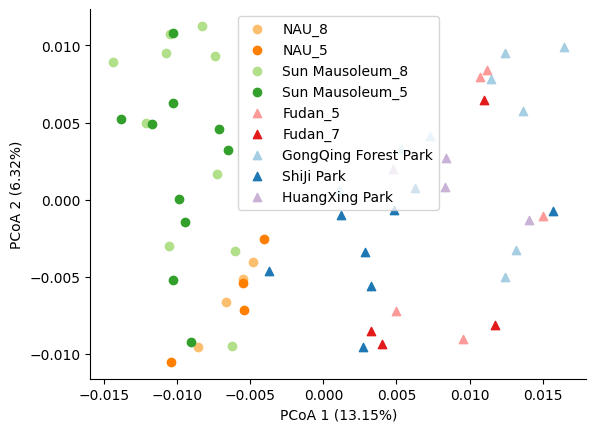

In [91]:
fig, ax = plt.subplots()
ax.scatter(pc1_cpsnj1, pc2_cpsnj1,c='#fdbf6f', label='NAU_8')
ax.scatter(pc1_snj1, pc2_snj1,c='#ff7f00', label='NAU_5')
ax.scatter(pc1_cpsnj2, pc2_cpsnj2,c='#b2df8a',label='Sun Mausoleum_8')
ax.scatter(pc1_snj2, pc2_snj2,c='#33a02c', label='Sun Mausoleum_5')
ax.scatter(pc1_fd5, pc2_fd5,c='#fb9a99',marker='^', label='Fudan_5')
ax.scatter(pc1_fd7, pc2_fd7,c='#e31a1c',marker='^', label='Fudan_7')
ax.scatter(pc1_gq, pc2_gq,c='#a6cee3',marker='^', label='GongQing Forest Park')
ax.scatter(pc1_sj, pc2_sj,c='#1f78b4',marker='^', label='ShiJi Park')
ax.scatter(pc1_hx, pc2_hx,c='#cab2d6',marker='^', label='HuangXing Park')
plt.legend()
ax.set_xlabel('PCoA 1 (13.15%)')
ax.set_ylabel('PCoA 2 (6.32%)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('/mnt/d/soil/manuscript/draft/mine/pcoa_bc_3.18.svg')

In [92]:
otu_tab = pd.read_csv('/mnt/d/soil/profile/otu/all_otu_table.S3.37.uS4_arch.ebd', sep='\t', index_col=0)
otu_tab

,AAACGGCAAAGTGGTGAACATCGCTTCTTATACCTGCAAGGCAGGAGATATCATCGCTGT,AACCGCCAGCTGGTCAGTCACGGTCACGTCAAAGTGAACGGCAAGCGGGTCAACATCGCG,AAGCGGCAGATCGTCGCGCACGGGCACGTGATCGCGAACGGCCGCAAGACCGACATCGCC,ACAAGACAAATCGTTTCTCATGGCCATATTTGTATCAACGGGCGAAAAACGAACATTCCT,ACAAGACAATTGGTAAGCCACAAACATGTTACCGTAAATGGTGATGTAGTGAATGTTCCT,ACAAGGCAGATCGTCGCCCACGGGCACGTGCTGGTGAACGGGCGTAAGACCGATATCCCC,ACAAGGCAGATCGTCGCTCACGGGCACGTGCTGGTGAACGGGCGTAAGACCGATATCCCC,ACAAGGCAGATCGTGGCACACGGTCACGTGCTTGTGGATGGCCGCAAGACCGATATCGCG,ACAAGGCAGGTCGTCGCCCACGGGCACGTGCTGGTGAACGGGCGCAAGACCGATATCCCC,ACAAGGCAGGTCGTCGCCCACGGGCACGTGCTGGTGACCGGGCGCAAGACCGATATCCCC,...,TGGAGACAGGGTCATCACCATTCCATCATACATTGTAAATATCAAAGAAGAAGGGCTCAT,TGGCGACAGATGGTGGCGCACGGCCACTTCGCCGTGAACGGCCGCAAGGTGTCGGTGCCG,TGGCGACAGCTGGTAACCCATGGTCACAGTCTGATCATTGGTCGCCGCACCGATAGTCCG,TGGCGGCAGATGGTGGCCCACGGCCACTTCCAGGTCAACGGCCGCAAGGTGTCGGTGCCG,TGTCGCTTATCGGCTGGGTTTTGCCAGTTCTCGTGCGGAGGCCAGATTGTTAGTTCGCCA,TGTCGGCAGATCGTGGCCCACGGGCATGTGCTGGTCGATGGCCGAAAGACCGACATCCCC,TGTCGGCAGCTCGTGCTGCACGGGCACTACCTCGTCAACGGCAAGCGCGTGAACATCCCG,TGTCGTATATCGGCTCGGTCTGGCGACGTCGCGTGCGCAGGCGCGCCAGCTCGTTCGCCA,TGTCGTGTATCGGCTCGGCCTGGCGACGTCGCGTGCGCAGGCGCGCCAGCTCGTTCGCCA,TTGCGGCAGATGGTGGCCCACGGCCACTTCCAGGTCAACGGACGCAAGGCCAGCGTGCCG
CPSNJ01_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ02_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ03_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ04_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ08_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ09_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ10_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ11_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ13_350,0.0,0.0,0.0,0.0,0.0,6.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPSNJ14_350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [93]:
#remove samples (<100 total count OTUs)
otus_filt = otu_tab[otu_tab.sum(axis=1) >= 100]
otus_filt_wo0 = otus_filt[otus_filt.sum(axis=1) > 0]
otus_filt_wo0 = otus_filt_wo0.loc[:,otus_filt_wo0.sum(axis=0) > 0]

otus_filt_wo0['Sum'] = otus_filt_wo0.sum(axis=1)
otus_RA = otus_filt_wo0.iloc[:, :].div(otus_filt_wo0.Sum, axis=0)
otus_RA = otus_RA.drop(['Sum'], axis=1)

#remove low RA
otus_RA = otus_RA.T
otus_RA['Mean'] = otus_RA.mean(axis=1)
otus_RA_filt = otus_RA.loc[otus_RA['Mean'].between(0.00001, 1)]
otus_RA_filt = otus_RA_filt.drop(['Mean'], axis=1)
otus_RA_filt 

,CPSNJ01_350,CPSNJ02_350,CPSNJ03_350,CPSNJ04_350,CPSNJ08_350,CPSNJ09_350,CPSNJ10_350,CPSNJ11_350,CPSNJ13_350,CPSNJ14_350,...,SNJ08_350,SNJ09_350,SNJ10_350,SNJ11_350,SNJ13_350,SNJ14_350,SNJ15_350,SNJ16_350,SNJ19_350,SNJ20_350
ACAAGGCAGATCGTCGCCCACGGGCACGTGCTGGTGAACGGGCGTAAGACCGATATCCCC,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.001512,0.000000,...,0.00000,0.0,0.0,0.0,0.0,0.000254,0.0,0.0,0.0,0.000000
ACACGCCAGATCGTGGCGCATGGTCATGTGCTGATCGACGGCCGCAAGACCGATATCGCC,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.00000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000
ACACGGCAGATCGTGGCGCATGGACACGTTCTGTTGGATGGCCGCAAGACCGACATCGCC,0.0,0.0,0.000515,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.00000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000178
ACCCGCCAGATCGTCAACCACGGCCACGTCATCGTCGACGGCCGCAAGACCGACATCGCC,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.00024,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000178
ACCCGCCAGATCGTCGCCCACGGCCACGTGCTGGTCGACGGCGTCAAGACCGACATCGCC,0.0,0.0,0.000515,0.000000,0.0,0.0,0.000199,0.0,0.000000,0.000000,...,0.00000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGCCGGCAGCTGGTGGCCCACGGCCACGTGATGGTCGATGGCCATAAAACCGACATCCCC,0.0,0.0,0.000000,0.000244,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.00000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000
TGCCGTCAGATCGTCCGCCACGGCCACATTACGGTCAACGGCCGCAAGGTCAATATTCCG,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.00000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000
TGCCGTCAGCTCGTGCGTCACGGGCACTTCCTCATCAACGGCAAGAAGGTCAACATCCCC,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.001066,...,0.00000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000
TGTCGGCAGATCGTGGCCCACGGGCATGTGCTGGTCGATGGCCGAAAGACCGACATCCCC,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.00000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000


In [94]:
otus_RA_filt_zoom = otus_RA_filt * 1000000
np.set_printoptions(precision=5)
otus_np = otus_RA_filt_zoom.to_numpy()

minval = np.min(otus_np[np.nonzero(otus_np)])
pseudo = minval/2
otus_RA_filt_zoom.replace([0],pseudo, inplace=True)

otus_RA_filt_zoom = otus_RA_filt_zoom.T
otus_RA_filt_zoom

,ACAAGGCAGATCGTCGCCCACGGGCACGTGCTGGTGAACGGGCGTAAGACCGATATCCCC,ACACGCCAGATCGTGGCGCATGGTCATGTGCTGATCGACGGCCGCAAGACCGATATCGCC,ACACGGCAGATCGTGGCGCATGGACACGTTCTGTTGGATGGCCGCAAGACCGACATCGCC,ACCCGCCAGATCGTCAACCACGGCCACGTCATCGTCGACGGCCGCAAGACCGACATCGCC,ACCCGCCAGATCGTCGCCCACGGCCACGTGCTGGTCGACGGCGTCAAGACCGACATCGCC,ACCCGCCAGATCGTCGCCCACGGCCACGTGCTGGTCGACGGCGTCAAGACGGACATCGCC,ACCCGCCAGATCGTCGCCCACGGCCACGTGCTGGTGGACGGCGTCAAGACCGACATCGCC,ACCCGCCAGATCGTCGCCCACGGCCATGTCCTGGTCGATGGCGTCAAGACCGACATCGCC,ACCCGCCAGATCGTCGCCCACGGCCATGTTCTGGTCGATGGCGTCAAGACCGATATCGCC,ACCCGCCAGATCGTCGCCCACGGGCACGTGCTCGTGAACGGCGTCAAGACCGACATCGCG,...,TGCCGCCAGGTGGTCCGCCATGGTCACGTCCAGGTGAACGGCCGCAAGGTCAACATACCG,TGCCGGCAGCTCGTGCGCCACGGGCACCTGCTCATCAACGGCAAGAAGGTCAACATCCCT,TGCCGGCAGCTCGTGCTGCACGGGCACTACCTCGTCAACGGCAAGCGCGTGAACATCCCC,TGCCGGCAGCTCGTGGCGCACGGGCACGTGGTGGTCAACGGTCGGAAGACGGACATCCCG,TGCCGGCAGCTGGTGCGCCACGGCCATTTCCTCATCAACGGCAAGAAGGTCAACATCCCC,TGCCGGCAGCTGGTGGCCCACGGCCACGTGATGGTCGATGGCCATAAAACCGACATCCCC,TGCCGTCAGATCGTCCGCCACGGCCACATTACGGTCAACGGCCGCAAGGTCAATATTCCG,TGCCGTCAGCTCGTGCGTCACGGGCACTTCCTCATCAACGGCAAGAAGGTCAACATCCCC,TGTCGGCAGATCGTGGCCCACGGGCATGTGCTGGTCGATGGCCGAAAGACCGACATCCCC,TGTCGGCAGCTCGTGCTGCACGGGCACTACCTCGTCAACGGCAAGCGCGTGAACATCCCG
CPSNJ01_350,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,...,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731
CPSNJ02_350,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,...,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731
CPSNJ03_350,79.897731,79.897731,515.463918,79.897731,515.463918,79.897731,79.897731,79.897731,79.897731,79.897731,...,79.897731,79.897731,515.463918,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731
CPSNJ04_350,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,...,79.897731,79.897731,79.897731,79.897731,79.897731,244.081035,79.897731,79.897731,79.897731,79.897731
CPSNJ08_350,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,...,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731
CPSNJ09_350,79.897731,79.897731,79.897731,79.897731,79.897731,300.030003,79.897731,79.897731,79.897731,79.897731,...,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731
CPSNJ10_350,79.897731,79.897731,79.897731,79.897731,198.807157,79.897731,79.897731,79.897731,79.897731,79.897731,...,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731
CPSNJ11_350,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,681.663258,...,79.897731,79.897731,681.663258,1363.326517,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731
CPSNJ13_350,1512.477943,79.897731,79.897731,79.897731,79.897731,252.079657,79.897731,79.897731,79.897731,79.897731,...,79.897731,79.897731,504.159314,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731
CPSNJ14_350,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,...,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,79.897731,1066.098081,79.897731,79.897731


In [95]:
np.set_printoptions(precision=5)
otus_rows = otus_RA_filt_zoom.index.tolist()
otus_cols = otus_RA_filt_zoom.columns.tolist()
otus_np = otus_RA_filt_zoom.to_numpy()

log_otus_tab = np.log10(otus_np)
otus_tab_F = pd.DataFrame(log_otus_tab, columns=otus_cols, index=otus_rows)
otus_tab_F

,ACAAGGCAGATCGTCGCCCACGGGCACGTGCTGGTGAACGGGCGTAAGACCGATATCCCC,ACACGCCAGATCGTGGCGCATGGTCATGTGCTGATCGACGGCCGCAAGACCGATATCGCC,ACACGGCAGATCGTGGCGCATGGACACGTTCTGTTGGATGGCCGCAAGACCGACATCGCC,ACCCGCCAGATCGTCAACCACGGCCACGTCATCGTCGACGGCCGCAAGACCGACATCGCC,ACCCGCCAGATCGTCGCCCACGGCCACGTGCTGGTCGACGGCGTCAAGACCGACATCGCC,ACCCGCCAGATCGTCGCCCACGGCCACGTGCTGGTCGACGGCGTCAAGACGGACATCGCC,ACCCGCCAGATCGTCGCCCACGGCCACGTGCTGGTGGACGGCGTCAAGACCGACATCGCC,ACCCGCCAGATCGTCGCCCACGGCCATGTCCTGGTCGATGGCGTCAAGACCGACATCGCC,ACCCGCCAGATCGTCGCCCACGGCCATGTTCTGGTCGATGGCGTCAAGACCGATATCGCC,ACCCGCCAGATCGTCGCCCACGGGCACGTGCTCGTGAACGGCGTCAAGACCGACATCGCG,...,TGCCGCCAGGTGGTCCGCCATGGTCACGTCCAGGTGAACGGCCGCAAGGTCAACATACCG,TGCCGGCAGCTCGTGCGCCACGGGCACCTGCTCATCAACGGCAAGAAGGTCAACATCCCT,TGCCGGCAGCTCGTGCTGCACGGGCACTACCTCGTCAACGGCAAGCGCGTGAACATCCCC,TGCCGGCAGCTCGTGGCGCACGGGCACGTGGTGGTCAACGGTCGGAAGACGGACATCCCG,TGCCGGCAGCTGGTGCGCCACGGCCATTTCCTCATCAACGGCAAGAAGGTCAACATCCCC,TGCCGGCAGCTGGTGGCCCACGGCCACGTGATGGTCGATGGCCATAAAACCGACATCCCC,TGCCGTCAGATCGTCCGCCACGGCCACATTACGGTCAACGGCCGCAAGGTCAATATTCCG,TGCCGTCAGCTCGTGCGTCACGGGCACTTCCTCATCAACGGCAAGAAGGTCAACATCCCC,TGTCGGCAGATCGTGGCCCACGGGCATGTGCTGGTCGATGGCCGAAAGACCGACATCCCC,TGTCGGCAGCTCGTGCTGCACGGGCACTACCTCGTCAACGGCAAGCGCGTGAACATCCCG
CPSNJ01_350,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,...,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534
CPSNJ02_350,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,...,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534
CPSNJ03_350,1.902534,1.902534,2.712198,1.902534,2.712198,1.902534,1.902534,1.902534,1.902534,1.902534,...,1.902534,1.902534,2.712198,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534
CPSNJ04_350,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,...,1.902534,1.902534,1.902534,1.902534,1.902534,2.387534,1.902534,1.902534,1.902534,1.902534
CPSNJ08_350,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,...,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534
CPSNJ09_350,1.902534,1.902534,1.902534,1.902534,1.902534,2.477165,1.902534,1.902534,1.902534,1.902534,...,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534
CPSNJ10_350,1.902534,1.902534,1.902534,1.902534,2.298432,1.902534,1.902534,1.902534,1.902534,1.902534,...,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534
CPSNJ11_350,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,2.833570,...,1.902534,1.902534,2.833570,3.134600,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534
CPSNJ13_350,3.179689,1.902534,1.902534,1.902534,1.902534,2.401538,1.902534,1.902534,1.902534,1.902534,...,1.902534,1.902534,2.702568,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534
CPSNJ14_350,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,...,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,1.902534,3.027797,1.902534,1.902534


In [96]:
bc_div = beta_diversity('braycurtis', log_otus_tab, ids=otus_rows, validate=True)
bc_pcoa = pcoa(bc_div)

In [97]:
metadata = pd.read_csv('../pre-calculated_data/metadata_otu.csv', index_col='Sample')
metadata.loc[metadata['Site'].str.startswith('NanJing'), 'Site'] = 'NanJing'
metadata.loc[metadata['Site'].str.startswith('ShangHai'), 'Site'] = 'ShangHai'
results = anosim(bc_div, metadata, column='Site', permutations=999)
results

method name                 ANOSIM
test statistic name              R
sample size                     58
number of groups                 2
test statistic            0.746861
p-value                      0.001
number of permutations         999
Name: ANOSIM results, dtype: object

In [98]:
df = bc_pcoa.samples
pc1_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC1']
pc2_cpsnj1 = df.loc[['CPSNJ01_350','CPSNJ02_350','CPSNJ03_350','CPSNJ04_350']]['PC2']
pc1_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC1']
pc2_cpsnj2 = df.loc[['CPSNJ08_350','CPSNJ09_350','CPSNJ10_350','CPSNJ11_350','CPSNJ13_350','CPSNJ14_350','CPSNJ15_350','CPSNJ16_350','CPSNJ19_350','CPSNJ20_350']]['PC2']
pc1_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC1']
pc2_snj1 = df.loc[['SNJ01_350','SNJ02_350','SNJ03_350','SNJ04_350']]['PC2']
pc2_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC2']
pc1_snj2 = df.loc[['SNJ08_350','SNJ09_350','SNJ10_350','SNJ11_350','SNJ13_350','SNJ14_350','SNJ15_350','SNJ16_350','SNJ19_350','SNJ20_350']]['PC1']
#pc1_sh = df.loc[df.index.str.match('^\d+' )]['PC1']
#pc2_sh = df.loc[df.index.str.match('^\d+' )]['PC2']
pc1_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC1']
pc2_fd5 = df.loc[['1_350','2_350','3_350','4_350','5_350']]['PC2']
pc1_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC1']
pc2_fd7 = df.loc[['6_350','7_350','8_350','9_350']]['PC2']
pc1_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC1']
pc2_gq = df.loc[['10_350','11_350','12_350','13_350','14_350','15_350','16_350','17_350','18_350']]['PC2']
pc1_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC1']
pc2_sj = df.loc[['23_350','24_350','25_350','26_350','27_350','28_350','29_350','30_350']]['PC2']
pc1_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC1']
pc2_hx = df.loc[['19_350','20_350','21_350','22_350']]['PC2']
bc_pcoa.proportion_explained

PC1     0.117899
PC2     0.061431
PC3     0.041658
PC4     0.037574
PC5     0.033256
PC6     0.025657
PC7     0.024952
PC8     0.022846
PC9     0.021020
PC10    0.020434
PC11    0.019766
PC12    0.018521
PC13    0.018392
PC14    0.017608
PC15    0.017369
PC16    0.016924
PC17    0.016559
PC18    0.015945
PC19    0.015787
PC20    0.015319
PC21    0.014957
PC22    0.014857
PC23    0.014544
PC24    0.014293
PC25    0.014132
PC26    0.013845
PC27    0.013745
PC28    0.013375
PC29    0.013301
PC30    0.013159
PC31    0.013050
PC32    0.012729
PC33    0.012665
PC34    0.012219
PC35    0.012186
PC36    0.012021
PC37    0.011825
PC38    0.011734
PC39    0.011590
PC40    0.011122
PC41    0.010895
PC42    0.010888
PC43    0.010679
PC44    0.010483
PC45    0.010344
PC46    0.010239
PC47    0.010053
PC48    0.009700
PC49    0.009516
PC50    0.009231
PC51    0.009084
PC52    0.008864
PC53    0.008591
PC54    0.008430
PC55    0.008269
PC56    0.007843
PC57    0.006629
PC58    0.000000
dtype: float64

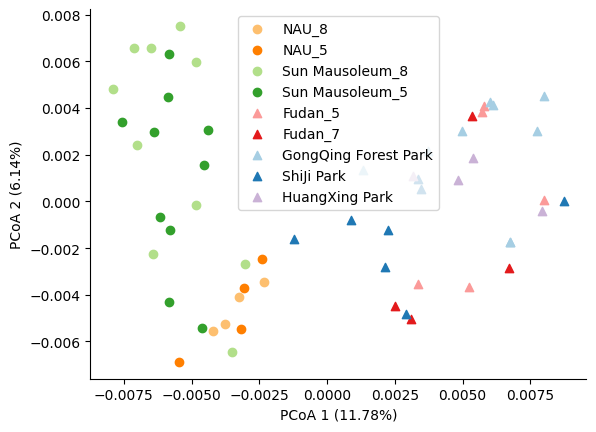

In [100]:
fig, ax = plt.subplots()
ax.scatter(pc1_cpsnj1, pc2_cpsnj1,c='#fdbf6f', label='NAU_8')
ax.scatter(pc1_snj1, pc2_snj1,c='#ff7f00', label='NAU_5')
ax.scatter(pc1_cpsnj2, pc2_cpsnj2,c='#b2df8a',label='Sun Mausoleum_8')
ax.scatter(pc1_snj2, pc2_snj2,c='#33a02c', label='Sun Mausoleum_5')
ax.scatter(pc1_fd5, pc2_fd5,c='#fb9a99',marker='^', label='Fudan_5')
ax.scatter(pc1_fd7, pc2_fd7,c='#e31a1c',marker='^', label='Fudan_7')
ax.scatter(pc1_gq, pc2_gq,c='#a6cee3',marker='^', label='GongQing Forest Park')
ax.scatter(pc1_sj, pc2_sj,c='#1f78b4',marker='^', label='ShiJi Park')
ax.scatter(pc1_hx, pc2_hx,c='#cab2d6',marker='^', label='HuangXing Park')
plt.legend()
ax.set_xlabel('PCoA 1 (11.78%)')
ax.set_ylabel('PCoA 2 (6.14%)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('/mnt/d/soil/manuscript/draft/mine/pcoa_bc_3.37.svg')